In [19]:
import os
import random
import numpy as np
from PIL import Image
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [20]:
# Build (image, mask) pairs from original folders + augmented folders
PROJECT = r"C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\project"
TAGS = ["L1000765", "L1000766", "L1000767", "L1000768"]

pairs = []

# 1) Original images + closed components masks
for tag in TAGS:
    crops_dir = os.path.join(PROJECT, tag, f"crops_{tag}")
    masks_dir = os.path.join(PROJECT, tag, f"closed_components_{tag}")

    if not (os.path.isdir(crops_dir) and os.path.isdir(masks_dir)):
        print(f"[skip] missing dirs for {tag}")
        continue

    crop_names = [n for n in os.listdir(crops_dir) if n.lower().endswith(".jpg")]
    for crop_name in crop_names:
        # crop_12.jpg -> idx=12 -> closed_component_12.jpg
        idx = crop_name.replace("crop_", "").replace(".jpg", "")
        mask_name = f"closed_component_{idx}.jpg"

        img_path = os.path.join(crops_dir, crop_name)
        mask_path = os.path.join(masks_dir, mask_name)

        if os.path.isfile(mask_path):
            pairs.append((img_path, mask_path))

# 2) Augmented images + augmented masks
aug_dir = os.path.join(PROJECT, "aug")
aug_masks_dir = os.path.join(PROJECT, "aug_masks")

if os.path.isdir(aug_dir) and os.path.isdir(aug_masks_dir):
    aug_names = [n for n in os.listdir(aug_dir) if n.lower().endswith(".jpg")]
    for name in aug_names:
        img_path = os.path.join(aug_dir, name)
        mask_path = os.path.join(aug_masks_dir, name)
        if os.path.isfile(mask_path):
            pairs.append((img_path, mask_path))

print(f"Total paired samples: {len(pairs)}")
if len(pairs) == 0:
    raise RuntimeError("No valid image-mask pairs found.")

# Train/val split
train_pairs, val_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)
print(f"Train pairs: {len(train_pairs)} | Val pairs: {len(val_pairs)}")

Total paired samples: 1768
Train pairs: 1414 | Val pairs: 354


In [21]:
# Dataset and DataLoaders
IMG_SIZE = 256
BATCH_SIZE = 8


def letterbox(img, target_size=IMG_SIZE, fill=255, interpolation=Image.BILINEAR):
    w, h = img.size
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    img = img.resize((new_w, new_h), interpolation)

    pad_w = target_size - new_w
    pad_h = target_size - new_h
    padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)

    return TF.pad(img, padding, fill=fill)


def load_aligned_mask(mask_path, img_h, img_w):
    closed_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if closed_mask is None:
        raise FileNotFoundError(f"Mask not found or unreadable: {mask_path}")

    # Handle fully empty masks safely (boundingRect would be zero-size)
    if np.count_nonzero(closed_mask) == 0:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    x, y, w, h = cv2.boundingRect(closed_mask)

    # Defensive guard against degenerate boxes
    if w <= 0 or h <= 0:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    mask_crop = closed_mask[y:y+h, x:x+w]
    if mask_crop.size == 0:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    if mask_crop.shape[:2] != (img_h, img_w):
        mask_crop = cv2.resize(mask_crop, (img_w, img_h), interpolation=cv2.INTER_NEAREST)

    return mask_crop


def preprocess_pair(img_path, mask_path):
    """Load, align, letterbox and convert one (image, mask) pair to tensors."""
    img = Image.open(img_path).convert("RGB")
    img_array = np.array(img)
    H, W = img_array.shape[:2]

    mask_aligned = load_aligned_mask(mask_path, H, W)
    mask = Image.fromarray(mask_aligned)

    img = letterbox(img, IMG_SIZE, fill=255, interpolation=Image.BILINEAR)
    mask = letterbox(mask, IMG_SIZE, fill=0, interpolation=Image.NEAREST)

    img_t = TF.to_tensor(img)
    img_t = TF.normalize(img_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    mask_arr = np.array(mask, dtype=np.float32) / 255.0
    mask_arr = (mask_arr > 0.5).astype(np.float32)
    mask_t = torch.from_numpy(mask_arr).unsqueeze(0)

    return img_t, mask_t


class SegDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.augment = augment
        print(f"  Pre-loading {len(pairs)} samples into RAM...", flush=True)
        self.data = []
        for i, (img_path, mask_path) in enumerate(pairs):
            try:
                self.data.append(preprocess_pair(img_path, mask_path))
            except Exception as e:
                print(f"  [skip] {e}")
            if (i + 1) % 500 == 0:
                print(f"  {i + 1}/{len(pairs)} loaded", flush=True)
        print(f"  Done. {len(self.data)} samples ready.", flush=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_t, mask_t = self.data[idx]

        if self.augment:
            if random.random() < 0.5:
                img_t = TF.hflip(img_t)
                mask_t = TF.hflip(mask_t)
            if random.random() < 0.5:
                img_t = TF.vflip(img_t)
                mask_t = TF.vflip(mask_t)

        return img_t, mask_t


train_ds = SegDataset(train_pairs, augment=True)
val_ds = SegDataset(val_pairs, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

  Pre-loading 1414 samples into RAM...


KeyboardInterrupt: 

In [ ]:
# Simple U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(-1)
    targets = targets.view(-1)

    intersection = (probs * targets).sum()
    dice = (2.0 * intersection + eps) / (probs.sum() + targets.sum() + eps)
    return 1.0 - dice


def iou_score_from_logits(logits, targets, thresh=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()

    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = ((preds + targets) > 0).float().sum(dim=(1, 2, 3))
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetSmall().to(device)

bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Training loop
EPOCHS = 25

train_losses, val_losses = [], []
train_ious, val_ious = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = 0.0
    tr_iou = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)

        loss_bce = bce(logits, masks)
        loss_dice = dice_loss_from_logits(logits, masks)
        loss = 0.5 * loss_bce + 0.5 * loss_dice

        loss.backward()
        optimizer.step()

        tr_loss += loss.item() * imgs.size(0)
        tr_iou += iou_score_from_logits(logits.detach(), masks) * imgs.size(0)

    tr_loss /= len(train_ds)
    tr_iou /= len(train_ds)

    model.eval()
    va_loss = 0.0
    va_iou = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            loss_bce = bce(logits, masks)
            loss_dice = dice_loss_from_logits(logits, masks)
            loss = 0.5 * loss_bce + 0.5 * loss_dice

            va_loss += loss.item() * imgs.size(0)
            va_iou += iou_score_from_logits(logits, masks) * imgs.size(0)

    va_loss /= len(val_ds)
    va_iou /= len(val_ds)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_ious.append(tr_iou)
    val_ious.append(va_iou)

    scheduler.step()

    print(
        f"Epoch {epoch:2d}/{EPOCHS} | "
        f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} | "
        f"train_iou={tr_iou:.4f} val_iou={va_iou:.4f}"
    )

# Save model
model_path = os.path.join(PROJECT, "segmenter_unet_small.pth")
torch.save(model.state_dict(), model_path)
print(f"Saved model: {model_path}")

Epoch  1/25 | train_loss=0.3354 val_loss=0.3035 | train_iou=0.6752 val_iou=0.7139
Epoch  2/25 | train_loss=0.2633 val_loss=0.2654 | train_iou=0.7246 val_iou=0.7183
Epoch  3/25 | train_loss=0.2370 val_loss=0.2484 | train_iou=0.7410 val_iou=0.7616
Epoch  4/25 | train_loss=0.2208 val_loss=0.3882 | train_iou=0.7588 val_iou=0.6939
Epoch  5/25 | train_loss=0.2117 val_loss=0.2161 | train_iou=0.7612 val_iou=0.7738
Epoch  6/25 | train_loss=0.2066 val_loss=0.2328 | train_iou=0.7682 val_iou=0.7702
Epoch  7/25 | train_loss=0.2011 val_loss=0.2067 | train_iou=0.7685 val_iou=0.7763
Epoch  8/25 | train_loss=0.1984 val_loss=0.3356 | train_iou=0.7716 val_iou=0.7169
Epoch  9/25 | train_loss=0.1890 val_loss=0.1836 | train_iou=0.7795 val_iou=0.7942
Epoch 10/25 | train_loss=0.1844 val_loss=0.1872 | train_iou=0.7838 val_iou=0.7942
Epoch 11/25 | train_loss=0.1840 val_loss=0.2169 | train_iou=0.7838 val_iou=0.7556
Epoch 12/25 | train_loss=0.1815 val_loss=0.3315 | train_iou=0.7841 val_iou=0.7171
Epoch 13/25 | tr

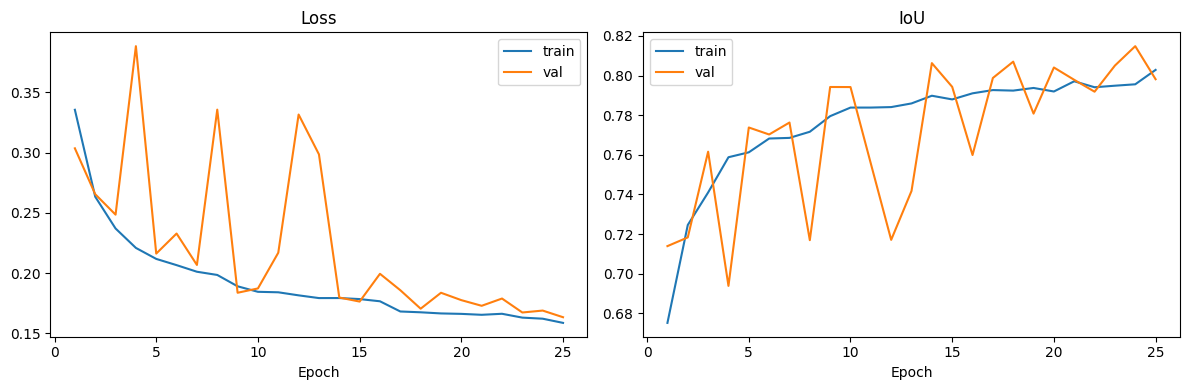

Best val IoU: 0.8148 at epoch 24


In [ ]:
# Curves
epochs_x = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_x, train_losses, label="train")
ax1.plot(epochs_x, val_losses, label="val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs_x, train_ious, label="train")
ax2.plot(epochs_x, val_ious, label="val")
ax2.set_title("IoU")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

best_epoch = int(np.argmax(val_ious)) + 1
print(f"Best val IoU: {max(val_ious):.4f} at epoch {best_epoch}")

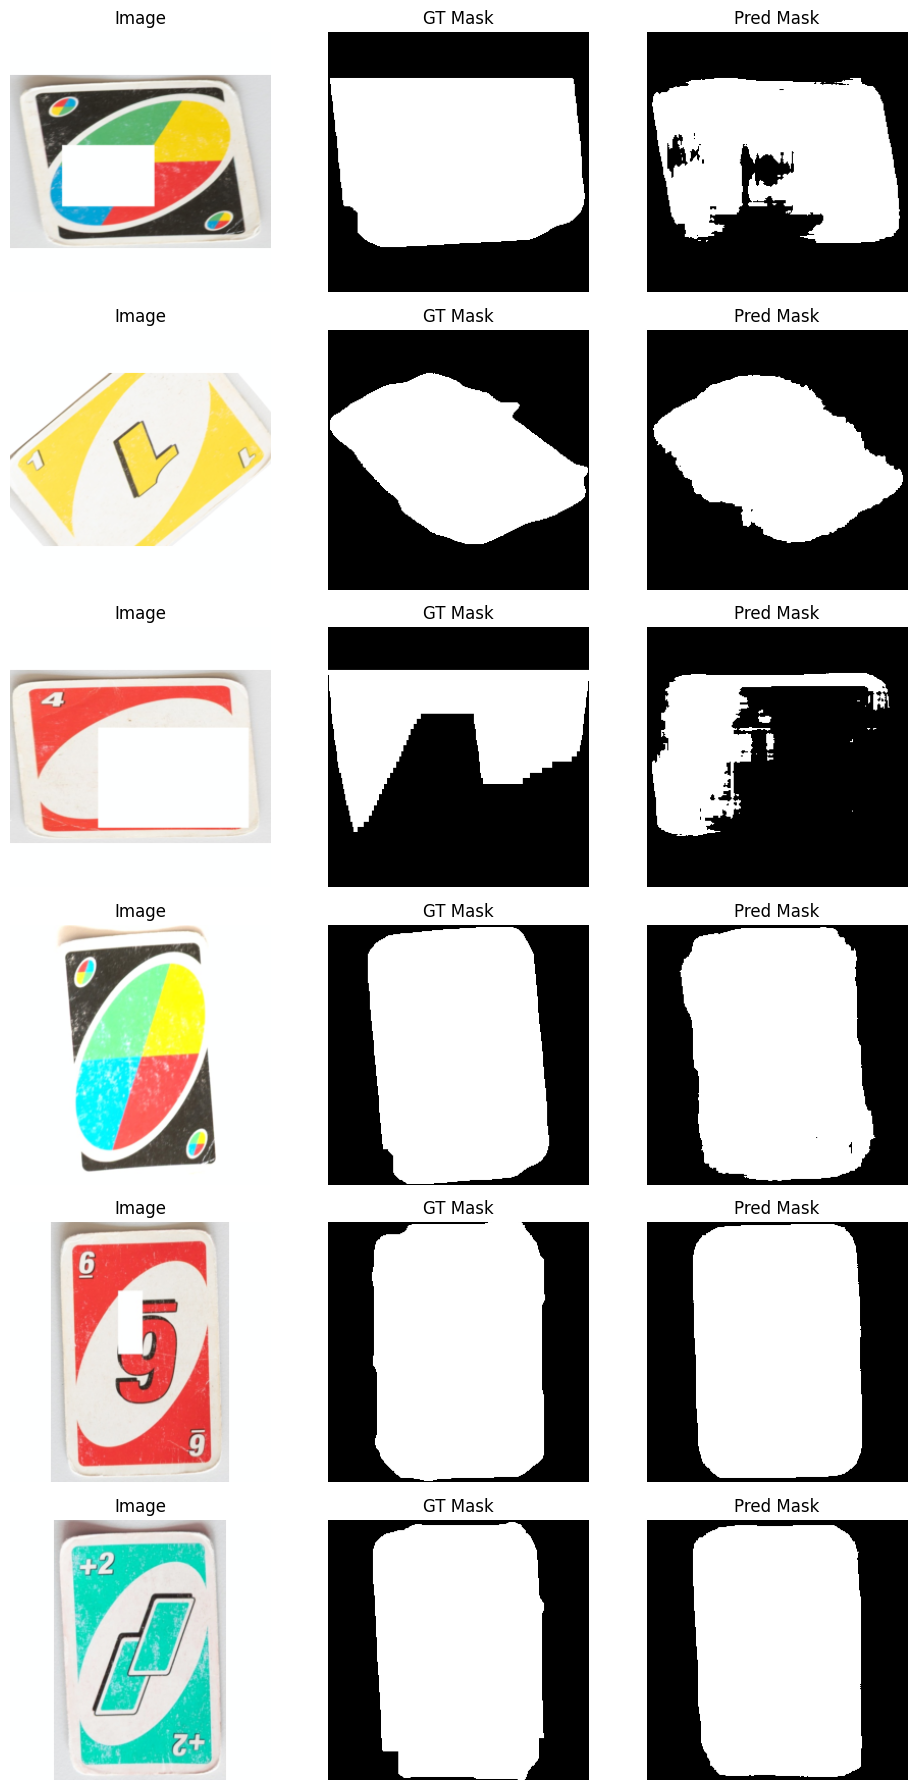

In [ ]:
# Qualitative validation predictions
model.eval()
num_show = 6

fig, axes = plt.subplots(num_show, 3, figsize=(10, 3 * num_show))

with torch.no_grad():
    for i in range(num_show):
        img_t, mask_t = val_ds[i]
        logits = model(img_t.unsqueeze(0).to(device))
        pred = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.float32)

        img_np = img_t.permute(1, 2, 0).numpy()
        img_np = (img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
        img_np = np.clip(img_np, 0, 1)

        gt = mask_t[0].numpy()

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("GT Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_bin, cmap="gray")
        axes[i, 2].set_title("Pred Mask")
        axes[i, 2].axis("off")

plt.tight_layout()
plt.show()